In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

In [20]:
df = pd.read_csv("./WineQT.csv",encoding="latin-1")

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [21]:
df.shape
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

In [22]:
X = df.drop("quality", axis=1).values
y = df["quality"].values

feature_names = df.drop("quality", axis=1).columns

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [24]:
X_train_bias = np.c_[np.ones(X_train.shape[0]), X_train]
X_test_bias = np.c_[np.ones(X_test.shape[0]), X_test]

In [25]:
def ridge_regression(X, y, lam):
    I = np.eye(X.shape[1])
    I[0, 0] = 0

    weights = np.linalg.inv(
        X.T @ X + lam * I
    ) @ X.T @ y

    return weights

In [26]:
lambdas = [0, 0.1, 1, 10]

results = []

for lam in lambdas:
    weights = ridge_regression(X_train_bias, y_train, lam)

    predictions = X_test_bias @ weights
    mse = mean_squared_error(y_test, predictions)

    results.append([lam, mse])

results_df = pd.DataFrame(
    results,
    columns=["Lambda", "Test_MSE"]
)

results_df

,Lambda,Test_MSE
0,0.0,0.382428
1,0.1,0.379796
2,1.0,0.375642
3,10.0,0.363912


In [27]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled_bias = np.c_[
    np.ones(X_train_scaled.shape[0]),
    X_train_scaled
]

X_test_scaled_bias = np.c_[
    np.ones(X_test_scaled.shape[0]),
    X_test_scaled
]

In [28]:
lam = 1

weights_unscaled = ridge_regression(
    X_train_bias,
    y_train,
    lam
)

weights_scaled = ridge_regression(
    X_train_scaled_bias,
    y_train,
    lam
)

In [29]:
comparison = pd.DataFrame({
    "Feature": ["Intercept"] + list(feature_names),
    "Without Scaling": weights_unscaled,
    "With Scaling": weights_scaled
})

comparison

,Feature,Without Scaling,With Scaling
0,Intercept,3.966300,5.656455
1,fixed acidity,0.020590,0.075949
2,volatile acidity,-1.341602,-0.236924
3,citric acid,-0.323762,-0.061657
4,residual sugar,-0.011554,0.006147
5,chlorides,-1.085320,-0.087131
6,free sulfur dioxide,0.003059,0.028448
7,total sulfur dioxide,-0.002590,-0.082549
8,density,-0.019552,-0.063062
9,pH,-0.354424,-0.043105


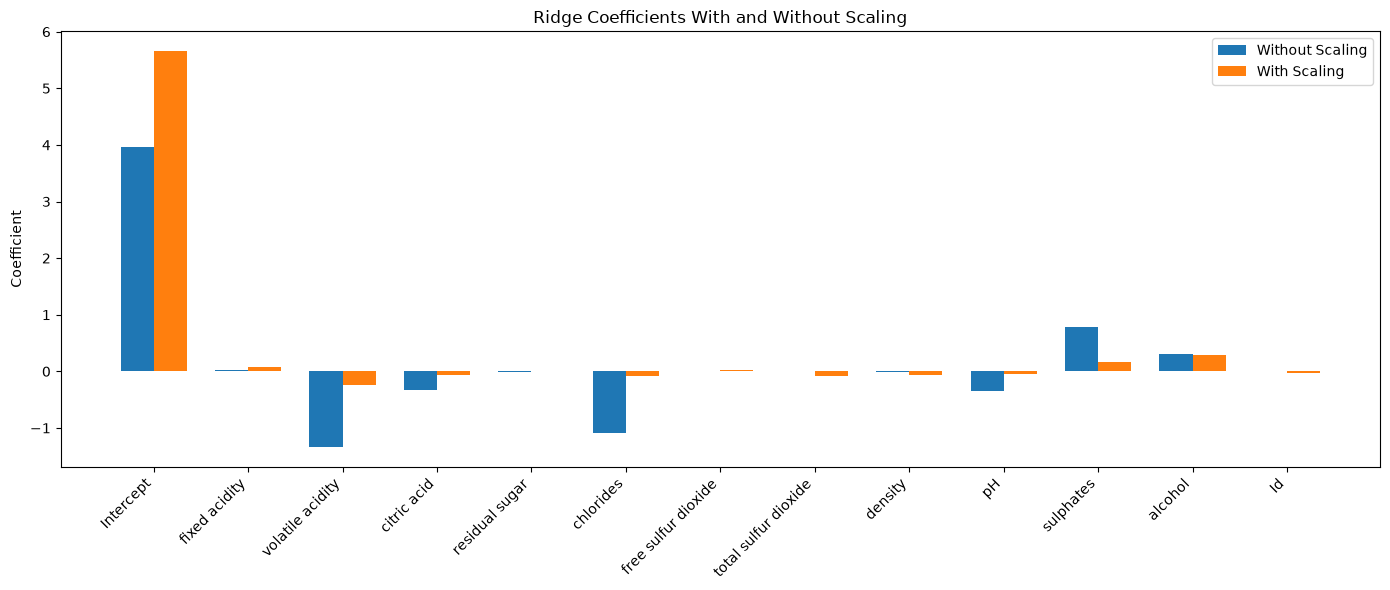

In [30]:
x = np.arange(len(feature_names) + 1)
width = 0.35

plt.figure(figsize=(14, 6))

plt.bar(
    x - width / 2,
    weights_unscaled,
    width,
    label="Without Scaling"
)

plt.bar(
    x + width / 2,
    weights_scaled,
    width,
    label="With Scaling"
)

plt.xticks(x, ["Intercept"] + list(feature_names), rotation=45, ha="right")
plt.ylabel("Coefficient")
plt.title("Ridge Coefficients With and Without Scaling")
plt.legend()
plt.tight_layout()
plt.show()

In [31]:
lambda_values = np.logspace(-4, 4, 100)

coefficients = []

for lam in lambda_values:
    weights = ridge_regression(
        X_train_scaled_bias,
        y_train,
        lam
    )

    coefficients.append(weights[1:])

coefficients = np.array(coefficients)

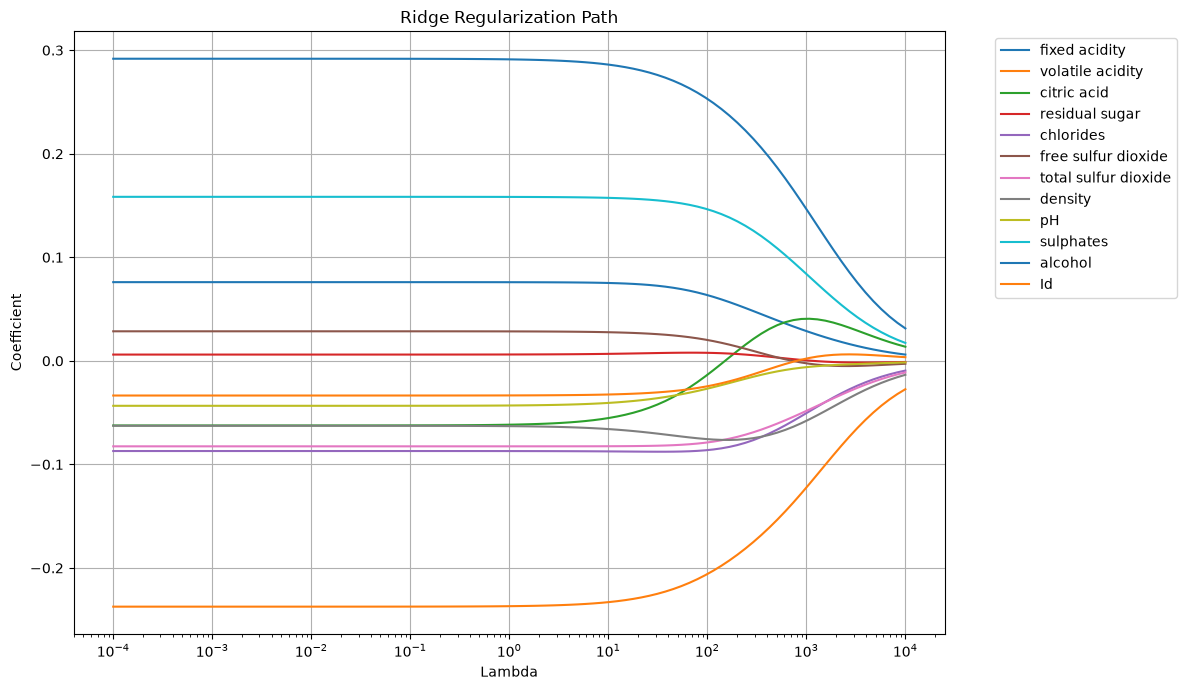

In [32]:
plt.figure(figsize=(12, 7))

for i in range(coefficients.shape[1]):
    plt.plot(
        lambda_values,
        coefficients[:, i],
        label=feature_names[i]
    )

plt.xscale("log")
plt.xlabel("Lambda")
plt.ylabel("Coefficient")
plt.title("Ridge Regularization Path")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.show()

In [33]:
np.random.seed(42)

indices = np.random.permutation(len(X_train_scaled))

folds = np.array_split(indices, 5)

for i, fold in enumerate(folds):
    print(f"Fold {i + 1}: {len(fold)} samples")

Fold 1: 183 samples
Fold 2: 183 samples
Fold 3: 183 samples
Fold 4: 183 samples
Fold 5: 182 samples


In [34]:
lambda_values_cv = [0, 0.001, 0.01, 0.1, 1, 10]

cv_results = []

for lam in lambda_values_cv:
    fold_errors = []

    for i in range(5):
        val_indices = folds[i]

        train_indices = np.concatenate(
            [folds[j] for j in range(5) if j != i]
        )

        X_fold_train = X_train_scaled[train_indices]
        y_fold_train = y_train[train_indices]

        X_fold_val = X_train_scaled[val_indices]
        y_fold_val = y_train[val_indices]

        X_fold_train_bias = np.c_[
            np.ones(X_fold_train.shape[0]),
            X_fold_train
        ]

        X_fold_val_bias = np.c_[
            np.ones(X_fold_val.shape[0]),
            X_fold_val
        ]

        weights = ridge_regression(
            X_fold_train_bias,
            y_fold_train,
            lam
        )

        predictions = X_fold_val_bias @ weights

        mse = mean_squared_error(
            y_fold_val,
            predictions
        )

        fold_errors.append(mse)

    avg_error = np.mean(fold_errors)

    cv_results.append([
        lam,
        avg_error
    ])

In [35]:
cv_df = pd.DataFrame(
    cv_results,
    columns=["Lambda", "Average_Validation_MSE"]
)

cv_df

,Lambda,Average_Validation_MSE
0,0.000,0.436531
1,0.001,0.436530
2,0.010,0.436529
3,0.100,0.436513
4,1.000,0.436362
5,10.000,0.435119


In [36]:
best_lambda = cv_df.loc[
    cv_df["Average_Validation_MSE"].idxmin(),
    "Lambda"
]

best_lambda

np.float64(10.0)

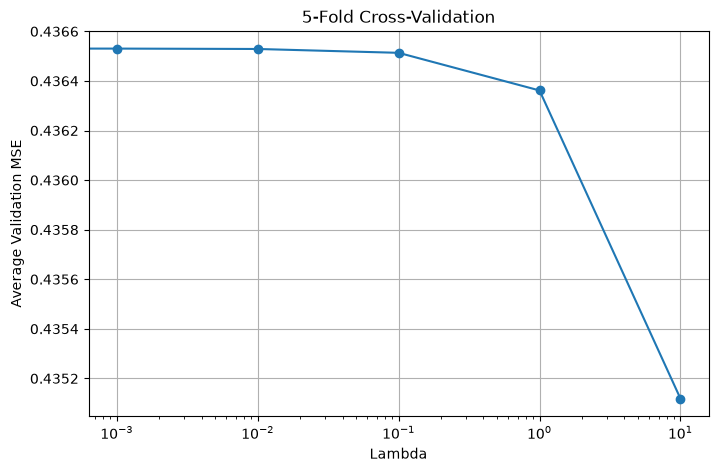

In [37]:
plt.figure(figsize=(8, 5))

plt.plot(
    cv_df["Lambda"],
    cv_df["Average_Validation_MSE"],
    marker="o"
)

plt.xscale("log")

plt.xlabel("Lambda")
plt.ylabel("Average Validation MSE")
plt.title("5-Fold Cross-Validation")

plt.grid(True)
plt.show()

In [38]:
train_errors = []
validation_errors = []

for lam in lambda_values_cv:
    fold_train_errors = []
    fold_val_errors = []

    for i in range(5):
        val_indices = folds[i]

        train_indices = np.concatenate(
            [folds[j] for j in range(5) if j != i]
        )

        X_fold_train = X_train_scaled[train_indices]
        y_fold_train = y_train[train_indices]

        X_fold_val = X_train_scaled[val_indices]
        y_fold_val = y_train[val_indices]

        X_fold_train_bias = np.c_[
            np.ones(X_fold_train.shape[0]),
            X_fold_train
        ]

        X_fold_val_bias = np.c_[
            np.ones(X_fold_val.shape[0]),
            X_fold_val
        ]

        weights = ridge_regression(
            X_fold_train_bias,
            y_fold_train,
            lam
        )

        train_pred = X_fold_train_bias @ weights
        val_pred = X_fold_val_bias @ weights

        fold_train_errors.append(
            mean_squared_error(y_fold_train, train_pred)
        )

        fold_val_errors.append(
            mean_squared_error(y_fold_val, val_pred)
        )

    train_errors.append(np.mean(fold_train_errors))
    validation_errors.append(np.mean(fold_val_errors))

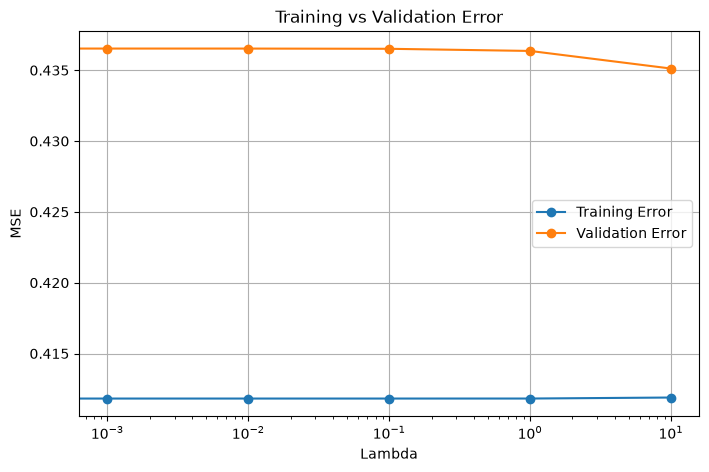

In [39]:
plt.figure(figsize=(8, 5))

plt.plot(
    lambda_values_cv,
    train_errors,
    marker="o",
    label="Training Error"
)

plt.plot(
    lambda_values_cv,
    validation_errors,
    marker="o",
    label="Validation Error"
)

plt.xscale("log")

plt.xlabel("Lambda")
plt.ylabel("MSE")
plt.title("Training vs Validation Error")

plt.legend()
plt.grid(True)
plt.show()

In [40]:
linear_weights = ridge_regression(
    X_train_scaled_bias,
    y_train,
    0
)

ridge_best_weights = ridge_regression(
    X_train_scaled_bias,
    y_train,
    best_lambda
)

ridge_high_weights = ridge_regression(
    X_train_scaled_bias,
    y_train,
    10000
)

In [41]:
linear_pred = X_test_scaled_bias @ linear_weights

ridge_best_pred = X_test_scaled_bias @ ridge_best_weights

ridge_high_pred = X_test_scaled_bias @ ridge_high_weights

In [42]:
model_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Optimal",
        "Ridge High Lambda"
    ],
    "Test MSE": [
        mean_squared_error(y_test, linear_pred),
        mean_squared_error(y_test, ridge_best_pred),
        mean_squared_error(y_test, ridge_high_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, linear_pred)),
        np.sqrt(mean_squared_error(y_test, ridge_best_pred)),
        np.sqrt(mean_squared_error(y_test, ridge_high_pred))
    ]
})

model_results

,Model,Test MSE,RMSE
0,Linear Regression,0.382428,0.618408
1,Ridge Optimal,0.381017,0.617266
2,Ridge High Lambda,0.501266,0.708001


In [43]:
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Linear Regression": np.abs(linear_weights[1:]),
    "Ridge Optimal": np.abs(ridge_best_weights[1:]),
    "Ridge High Lambda": np.abs(ridge_high_weights[1:])
})

importance_df

,Feature,Linear Regression,Ridge Optimal,Ridge High Lambda
0,fixed acidity,0.076003,0.075208,0.006048
1,volatile acidity,0.237378,0.233030,0.027387
2,citric acid,0.062404,0.055265,0.013641
3,residual sugar,0.006064,0.006755,0.001102
4,chlorides,0.087090,0.087442,0.009401
5,free sulfur dioxide,0.028537,0.027649,0.002830
6,total sulfur dioxide,0.082554,0.082459,0.011203
7,density,0.062696,0.065876,0.013471
8,pH,0.043410,0.040630,0.001519
9,sulphates,0.158405,0.157408,0.017312


In [44]:
importance_df.sort_values(
    "Ridge Optimal",
    ascending=False
)

,Feature,Linear Regression,Ridge Optimal,Ridge High Lambda
10,alcohol,0.291764,0.286107,0.031326
1,volatile acidity,0.237378,0.233030,0.027387
9,sulphates,0.158405,0.157408,0.017312
4,chlorides,0.087090,0.087442,0.009401
6,total sulfur dioxide,0.082554,0.082459,0.011203
0,fixed acidity,0.076003,0.075208,0.006048
7,density,0.062696,0.065876,0.013471
2,citric acid,0.062404,0.055265,0.013641
8,pH,0.043410,0.040630,0.001519
11,Id,0.033485,0.032499,0.003547


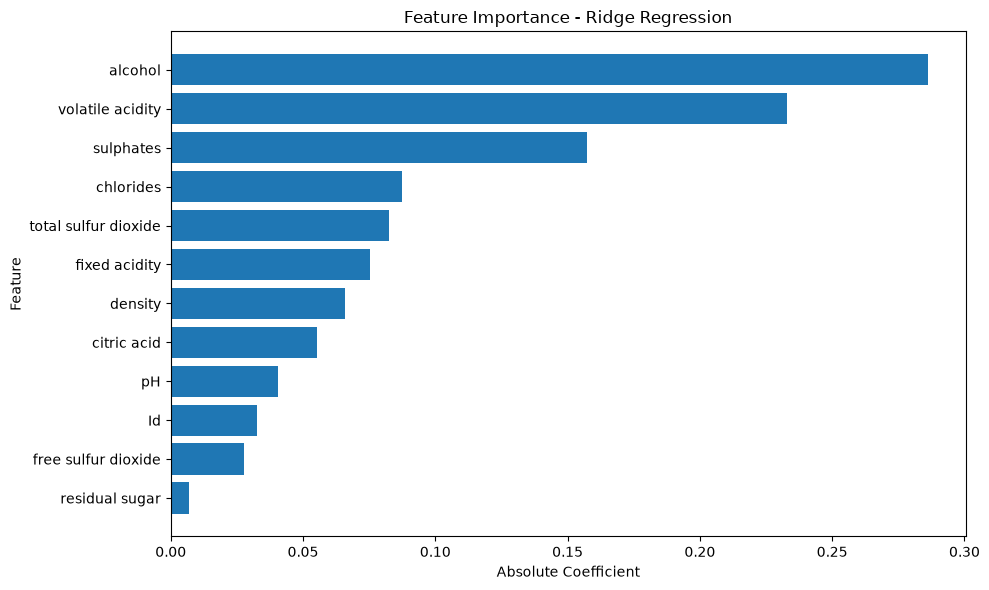

In [45]:
importance_plot = importance_df.sort_values(
    "Ridge Optimal"
)

plt.figure(figsize=(10, 6))

plt.barh(
    importance_plot["Feature"],
    importance_plot["Ridge Optimal"]
)

plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")
plt.title("Feature Importance - Ridge Regression")

plt.tight_layout()
plt.show()

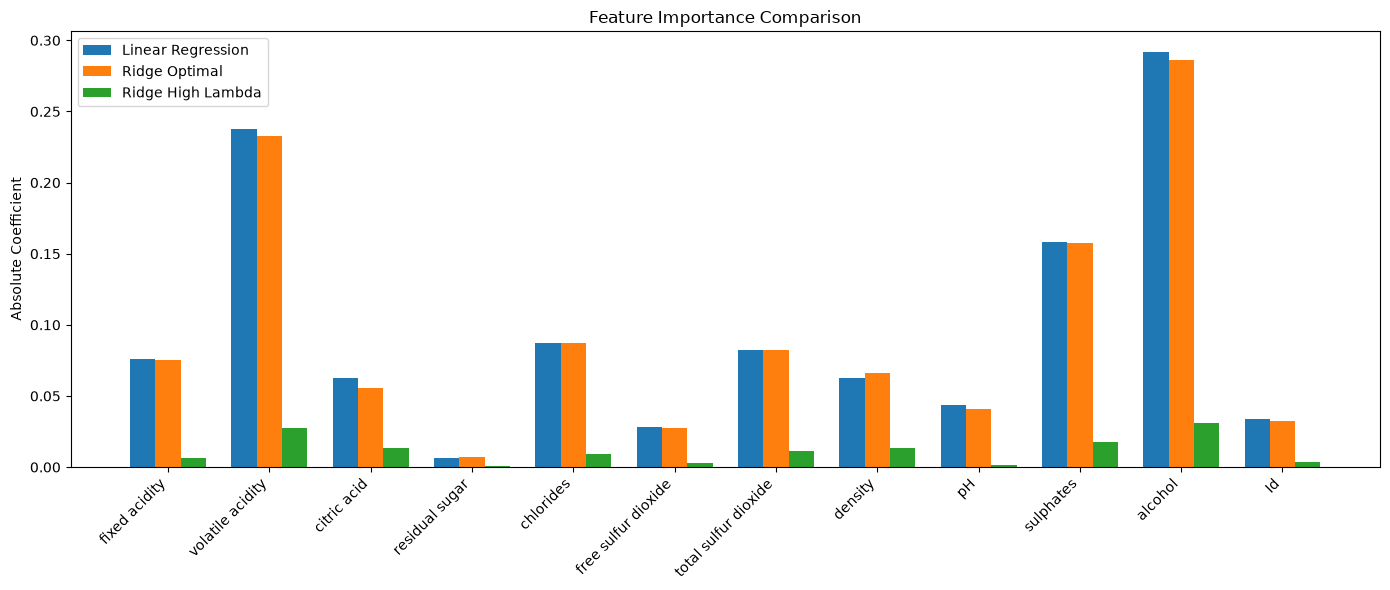

In [46]:
x = np.arange(len(feature_names))
width = 0.25

plt.figure(figsize=(14, 6))

plt.bar(
    x - width,
    importance_df["Linear Regression"],
    width,
    label="Linear Regression"
)

plt.bar(
    x,
    importance_df["Ridge Optimal"],
    width,
    label="Ridge Optimal"
)

plt.bar(
    x + width,
    importance_df["Ridge High Lambda"],
    width,
    label="Ridge High Lambda"
)

plt.xticks(
    x,
    feature_names,
    rotation=45,
    ha="right"
)

plt.ylabel("Absolute Coefficient")
plt.title("Feature Importance Comparison")
plt.legend()

plt.tight_layout()
plt.show()

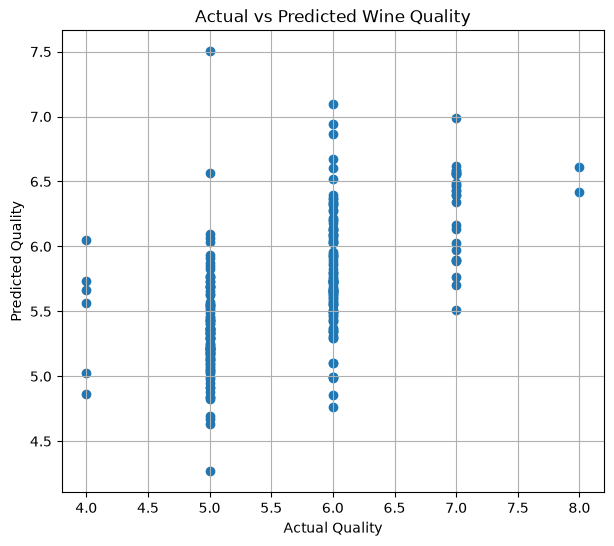

In [47]:
plt.figure(figsize=(7, 6))

plt.scatter(
    y_test,
    ridge_best_pred
)

plt.xlabel("Actual Quality")
plt.ylabel("Predicted Quality")
plt.title("Actual vs Predicted Wine Quality")

plt.grid(True)
plt.show()

In [48]:
summary = pd.DataFrame({
    "Lambda": lambda_values_cv,
    "Validation MSE": validation_errors,
    "Training MSE": train_errors
})

summary

,Lambda,Validation MSE,Training MSE
0,0.000,0.436531,0.411819
1,0.001,0.436530,0.411819
2,0.010,0.436529,0.411819
3,0.100,0.436513,0.411819
4,1.000,0.436362,0.411820
5,10.000,0.435119,0.411892


In [49]:
print("Best Lambda:", best_lambda)

Best Lambda: 10.0
